## 1. Dataset background

BETH is a real cybersecurity dataset collected from honeypots. The supplied BETH paper describes more than eight million events across 23 hosts, while the initial benchmark subset uses kernel-level process logs divided into training, validation and testing sets. The `evil` label identifies malicious events.

The supplied student project uses `evil` as the target and focuses on process/system-event features such as process IDs, user IDs, mount namespace, process/event names, event ID, argument count and return value.


In [18]:

import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.neighbors import LocalOutlierFactor
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve,
)

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", 100)
sns.set_theme(style="whitegrid")


## 2. Configure the dataset location
  filenames:

- `labelled_training_data.csv`
- `labelled_validation_data.csv`
- `labelled_testing_data.csv`



In [19]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [20]:
# google drive BETH dataset folder path
DATA_DIR = "/content/drive/MyDrive/datasets/BETH/"

# individual data files loading
TRAIN_FILE = DATA_DIR + "labelled_training_data.csv"
VAL_FILE   = DATA_DIR + "labelled_validation_data.csv"
TEST_FILE  = DATA_DIR + "labelled_testing_data.csv"

MAX_IF_TRAIN_SAMPLES = None
MAX_RF_TRAIN_SAMPLES = None
MAX_LOF_TRAIN_SAMPLES = None

print("Train:", TRAIN_FILE)
print("Validation:", VAL_FILE)
print("Test:", TEST_FILE)


Train: /content/drive/MyDrive/datasets/BETH/labelled_training_data.csv
Validation: /content/drive/MyDrive/datasets/BETH/labelled_validation_data.csv
Test: /content/drive/MyDrive/datasets/BETH/labelled_testing_data.csv


In [22]:
# my BETH datasets
train_df = pd.read_csv(TRAIN_FILE)
val_df = pd.read_csv(VAL_FILE)
test_df = pd.read_csv(TEST_FILE)

print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("Test shape:", test_df.shape)


Train shape: (763144, 16)
Validation shape: (188967, 16)
Test shape: (188967, 16)


In [23]:
display(train_df.tail())

,timestamp,processId,threadId,parentProcessId,userId,mountNamespace,processName,hostName,eventId,eventName,stackAddresses,argsNum,returnValue,args,sus,evil
763139,324.542553,7274,7274,7108,0,4026531840,sshd,ip-10-100-1-79,1003,cap_capable,[],1,0,"[{'name': 'cap', 'type': 'int', 'value': 'CAP_...",0,0
763140,324.542579,7274,7274,7108,0,4026531840,sshd,ip-10-100-1-79,62,kill,[],2,0,"[{'name': 'pid', 'type': 'pid_t', 'value': 0},...",0,0
763141,324.543178,7274,7274,7108,0,4026531840,sshd,ip-10-100-1-79,1010,sched_process_exit,[],0,0,[],0,0
763142,324.543695,7275,7275,1,109,4026531840,sshd,ip-10-100-1-79,1010,sched_process_exit,[],0,0,[],0,0
763143,324.543831,7108,7108,1,0,4026531840,sshd,ip-10-100-1-79,3,close,[140129105123719],1,0,"[{'name': 'fd', 'type': 'int', 'value': 6}]",0,0


In [24]:
# Inspecting  columns and first rows
print("Columns:")
print(train_df.columns.tolist())


Columns:
['timestamp', 'processId', 'threadId', 'parentProcessId', 'userId', 'mountNamespace', 'processName', 'hostName', 'eventId', 'eventName', 'stackAddresses', 'argsNum', 'returnValue', 'args', 'sus', 'evil']


In [25]:
display(train_df.head())

,timestamp,processId,threadId,parentProcessId,userId,mountNamespace,processName,hostName,eventId,eventName,stackAddresses,argsNum,returnValue,args,sus,evil
0,1809.495787,381,7337,1,100,4026532231,close,ip-10-100-1-120,157,prctl,"[140662171848350, 11649800180280676]",5,0,"[{'name': 'option', 'type': 'int', 'value': 'P...",1,0
1,1809.495832,381,7337,1,100,4026532231,close,ip-10-100-1-120,3,close,[140662171777451],1,0,"[{'name': 'fd', 'type': 'int', 'value': 19}]",1,0
2,1809.495921,381,7337,1,100,4026532231,close,ip-10-100-1-120,1010,sched_process_exit,[],0,0,[],1,0
3,1894.139651,7347,7347,7341,0,4026531840,sh,ip-10-100-1-120,21,access,[],2,-2,"[{'name': 'pathname', 'type': 'const char*', '...",1,0
4,1894.142127,7347,7347,7341,0,4026531840,sh,ip-10-100-1-120,1005,security_file_open,"[139778263990104, 139778263906698]",4,0,"[{'name': 'pathname', 'type': 'const char*', '...",1,0


In [26]:
# Basic dataset information
print("Missing values in training data:")
display(train_df.isna().sum().sort_values(ascending=False).head(20))


Missing values in training data:


,0
timestamp,0
processId,0
threadId,0
parentProcessId,0
userId,0
mountNamespace,0
processName,0
hostName,0
eventId,0
eventName,0


In [27]:

print("\nTarget distribution:")
for name, df in [("Train", train_df), ("Validation", val_df), ("Test", test_df)]:
    print(f"\n{name}")
    print(df["evil"].value_counts(dropna=False).sort_index())
    print(df["evil"].value_counts(normalize=True).sort_index())



Target distribution:

Train
evil
0    763144
Name: count, dtype: int64
evil
0    1.0
Name: proportion, dtype: float64

Validation
evil
0    188967
Name: count, dtype: int64
evil
0    1.0
Name: proportion, dtype: float64

Test
evil
0     30535
1    158432
Name: count, dtype: int64
evil
0    0.161589
1    0.838411
Name: proportion, dtype: float64


## 3. Evil-label frequency

The project report includes a class-frequency visualization because the BETH data is highly imbalanced. This plot is useful before training because accuracy alone can be misleading when the anomalous class is much smaller than the normal class.


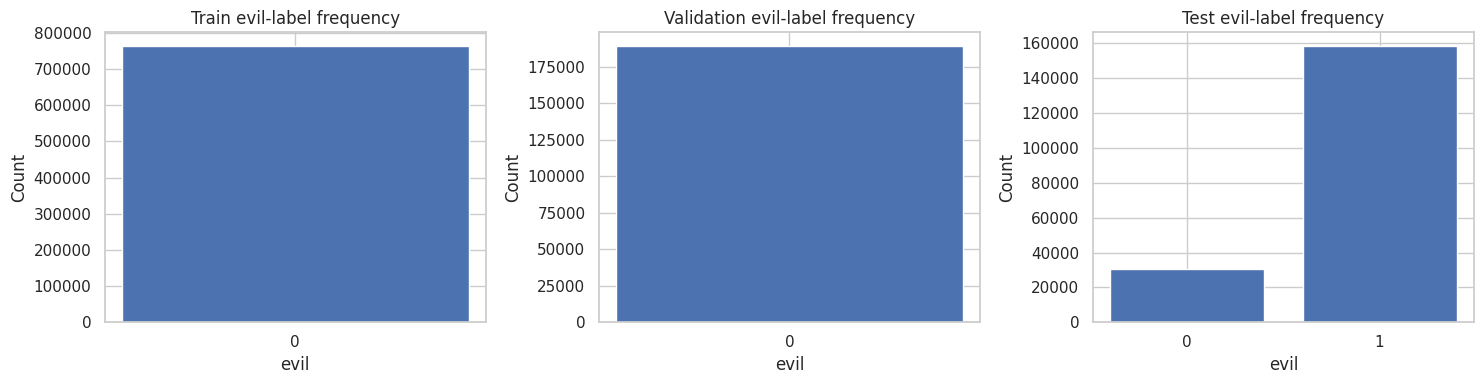

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

datasets = [
    ("Train", train_df),
    ("Validation", val_df),
    ("Test", test_df),
]

for ax, (name, df) in zip(axes, datasets):
    counts = df["evil"].value_counts().sort_index()
    ax.bar(counts.index.astype(str), counts.values)
    ax.set_title(f"{name} evil-label frequency")
    ax.set_xlabel("evil")
    ax.set_ylabel("Count")

plt.tight_layout()
plt.show()


## 4. Feature selection and preprocessing

the main model features are:

- `processId`
- `parentProcessId`
- `userId`
- `mountNamespace`
- `processName`
- `eventId`
- `eventName`
- `argsNum`
- `returnValue`

 `timestamp`, `threadId`, `stackAddresses` and `args` were removed from dataset.



In [32]:
FEATURES = [
    "processId",
    "parentProcessId",
    "userId",
    "mountNamespace",
    "processName",
    "eventId",
    "eventName",
    "argsNum",
    "returnValue",
]

TARGET = "evil"

required_columns = FEATURES + [TARGET]

for name, df in [("train", train_df), ("validation", val_df), ("test", test_df)]:
    missing = [c for c in required_columns if c not in df.columns]
    if missing:
        raise ValueError(f"{name} is missing required columns: {missing}")

print("All required columns are present.")


All required columns are present.


In [33]:
def basic_beth_mapping(df):
    """Apply the project-style preprocessing to numeric system fields."""
    df = df.copy()

    # Process IDs: OS/system processes vs other processes
    df["processId"] = df["processId"].apply(
        lambda x: 0 if x in [0, 1, 2] else 1
    )

    # Parent process IDs
    df["parentProcessId"] = df["parentProcessId"].apply(
        lambda x: 0 if x in [0, 1, 2] else 1
    )

    # User IDs: system users vs non-system users
    df["userId"] = df["userId"].apply(
        lambda x: 0 if x < 1000 else 1
    )

    # Mount namespace: main OS namespace vs other namespace
    df["mountNamespace"] = df["mountNamespace"].apply(
        lambda x: 0 if x == 4026531840 else 1
    )


    # Return value:
    # 0 = zero/success
    # 1 = positive return value
    # 2 = negative/error return value
    df["returnValue"] = df["returnValue"].apply(
        lambda x: 0 if x == 0 else (1 if x > 0 else 2)
    )

    return df


train_p = basic_beth_mapping(train_df)
val_p = basic_beth_mapping(val_df)
test_p = basic_beth_mapping(test_df)

print(train_p[FEATURES].head())


   processId  parentProcessId  userId  mountNamespace processName  eventId  \
0          1                0       0               1       close      157   
1          1                0       0               1       close        3   
2          1                0       0               1       close     1010   
3          1                1       0               0          sh       21   
4          1                1       0               0          sh     1005   

            eventName  argsNum  returnValue  
0               prctl        5            0  
1               close        1            0  
2  sched_process_exit        0            0  
3              access        2            2  
4  security_file_open        4            0  


In [34]:
process_encoder = LabelEncoder()
event_encoder = LabelEncoder()

all_process_names = pd.concat(
    [
        train_p["processName"].astype(str),
        val_p["processName"].astype(str),
        test_p["processName"].astype(str),
    ],
    ignore_index=True,
)

all_event_names = pd.concat(
    [
        train_p["eventName"].astype(str),
        val_p["eventName"].astype(str),
        test_p["eventName"].astype(str),
    ],
    ignore_index=True,
)

process_encoder.fit(all_process_names)
event_encoder.fit(all_event_names)

for df in [train_p, val_p, test_p]:
    df["processName"] = process_encoder.transform(df["processName"].astype(str))
    df["eventName"] = event_encoder.transform(df["eventName"].astype(str))

print("Unique process names:", len(process_encoder.classes_))
print("Unique event names:", len(event_encoder.classes_))

print("\nExample processName mapping:")
for i, value in enumerate(process_encoder.classes_[:10]):
    print(i, "->", value)

print("\nExample eventName mapping:")
for i, value in enumerate(event_encoder.classes_[:10]):
    print(i, "->", value)


Unique process names: 260
Unique event names: 46

Example processName mapping:
0 -> (activate)
1 -> (direxec)
2 -> (sd-executor)
3 -> (sd-pam)
4 -> (sd-sync)
5 -> (systemd)
6 -> (time-dir)
7 -> (tmpfiles)
8 -> (ystemctl)
9 -> 00-header

Example eventName mapping:
0 -> accept
1 -> accept4
2 -> access
3 -> bind
4 -> bpf
5 -> cap_capable
6 -> chmod
7 -> clone
8 -> close
9 -> connect


In [35]:
# Final numeric matrices
X_train_full = train_p[FEATURES].astype(np.float32)
y_train = train_p[TARGET].astype(int)

X_val = val_p[FEATURES].astype(np.float32)
y_val = val_p[TARGET].astype(int)

X_test = test_p[FEATURES].astype(np.float32)
y_test = test_p[TARGET].astype(int)

print("X_train:", X_train_full.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)


X_train: (763144, 9)
X_val: (188967, 9)
X_test: (188967, 9)


## 5. Correlation analysis


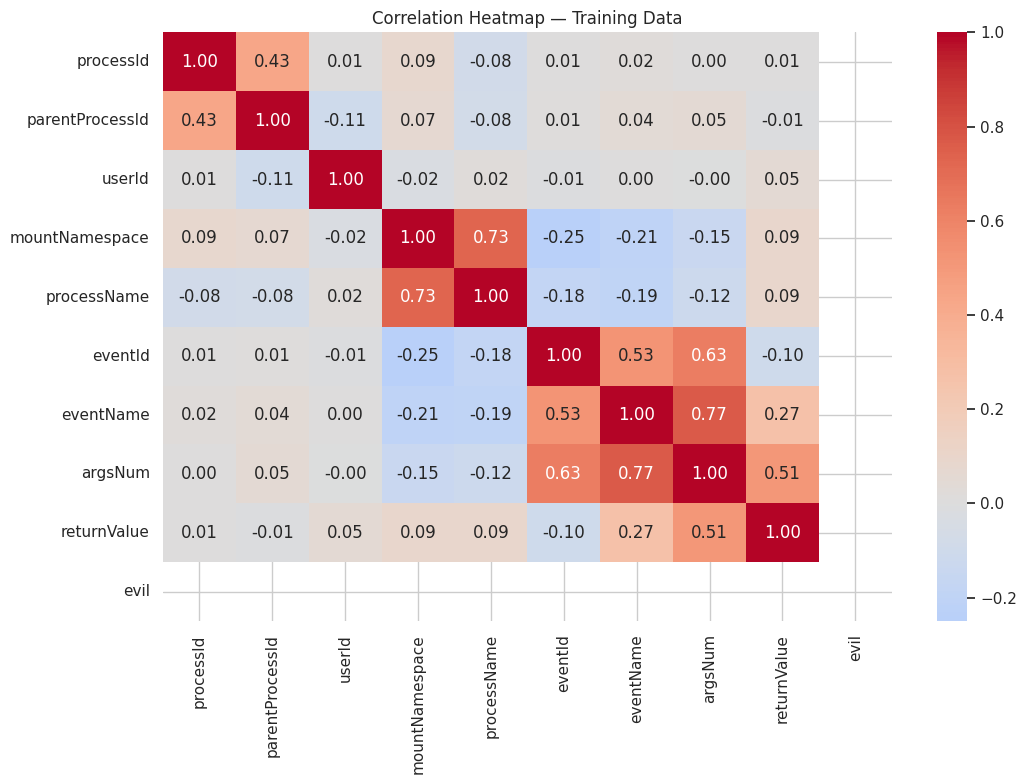

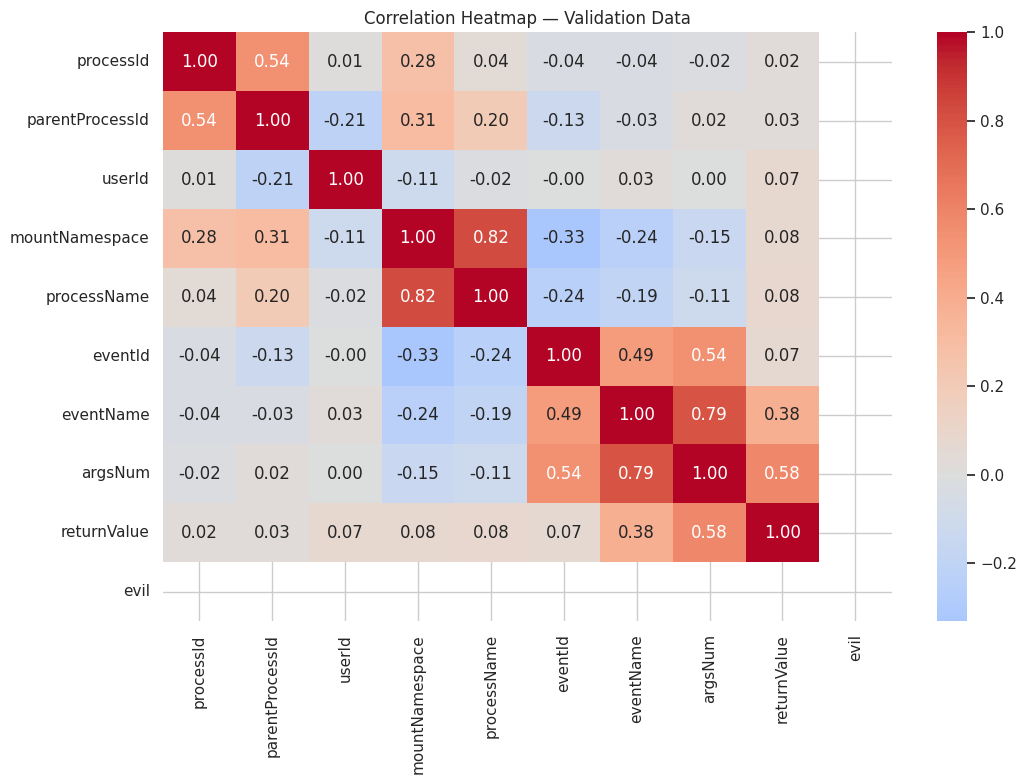

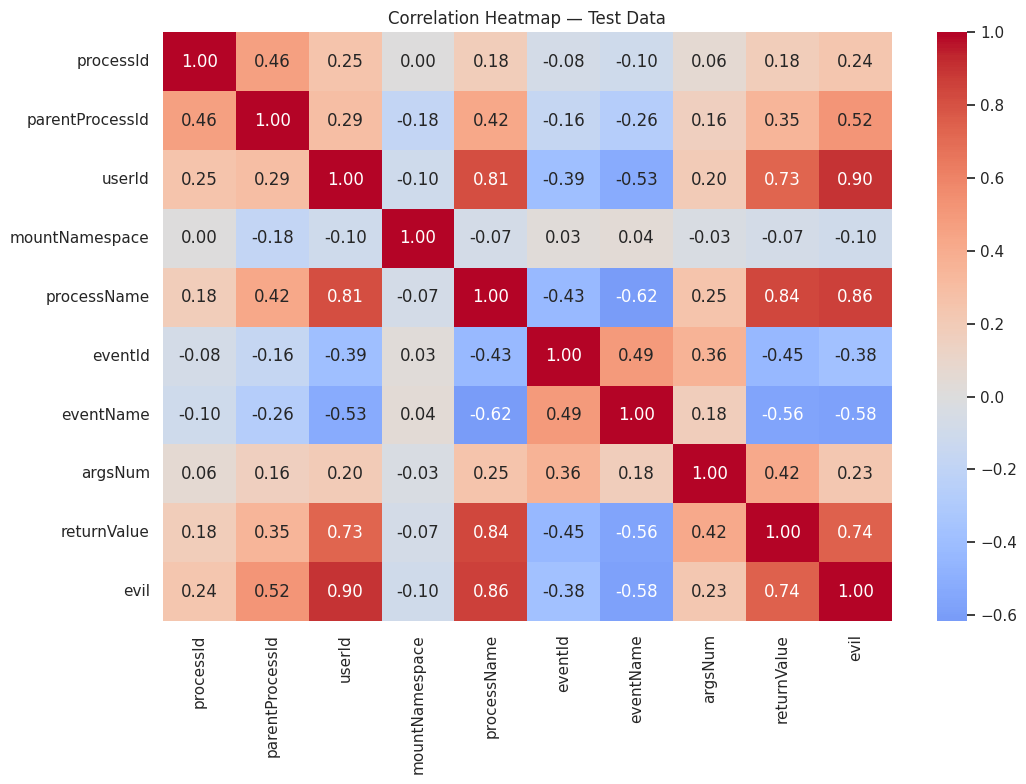

In [36]:
def plot_correlation_heatmap(df, title):
    corr = df[FEATURES + [TARGET]].corr(numeric_only=True)

    plt.figure(figsize=(11, 8))
    sns.heatmap(
        corr,
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        center=0,
        square=False
    )
    plt.title(title)
    plt.tight_layout()
    plt.show()

plot_correlation_heatmap(train_p, "Correlation Heatmap — Training Data")
plot_correlation_heatmap(val_p, "Correlation Heatmap — Validation Data")
plot_correlation_heatmap(test_p, "Correlation Heatmap — Test Data")


## 6. Optional training subsampling

In [37]:
def sample_training_data(X, y, max_samples, random_state=RANDOM_STATE):
    if max_samples is None or len(X) <= max_samples:
        return X, y

    rng = np.random.default_rng(random_state)
    indices = rng.choice(len(X), size=max_samples, replace=False)
    return X.iloc[indices], y.iloc[indices]


X_if, y_if = sample_training_data(
    X_train_full, y_train, MAX_IF_TRAIN_SAMPLES
)

X_rf, y_rf = sample_training_data(
    X_train_full, y_train, MAX_RF_TRAIN_SAMPLES
)

X_lof, y_lof = sample_training_data(
    X_train_full, y_train, MAX_LOF_TRAIN_SAMPLES
)

print("Isolation Forest training:", X_if.shape)
print("Random Forest training:", X_rf.shape)
print("LOF training:", X_lof.shape)


Isolation Forest training: (763144, 9)
Random Forest training: (763144, 9)
LOF training: (763144, 9)


# 7. Evaluation utilities

For every model we calculate:

- Accuracy
- Precision
- Recall
- F1-score
- Confusion matrix
- AUROC

For the anomaly-detection models, scikit-learn uses different prediction conventions. We convert them into one common convention:

- `0` = normal
- `1` = anomaly


In [38]:
def evaluate_model(name, y_true, y_pred, anomaly_score=None):
    print("=" * 70)
    print(name)
    print("=" * 70)

    # Determine unique classes in y_true
    unique_y_true_classes = np.unique(y_true)

    # Determine labels and target_names for classification_report
    if len(unique_y_true_classes) == 1:
        # If y_true contains only one class, adapt target_names and labels
        if 0 in unique_y_true_classes:
            report_labels = [0]
            report_target_names = ["Normal (0)"]
        elif 1 in unique_y_true_classes:
            report_labels = [1]
            report_target_names = ["Anomaly (1)"]
        else: # Handle other potential single classes if any
            report_labels = list(unique_y_true_classes)
            report_target_names = [f"Class ({c})" for c in unique_y_true_classes]
    else:
        # Standard case with two classes
        report_labels = [0, 1]
        report_target_names = ["Normal (0)", "Anomaly (1)"]

    print(classification_report(
        y_true,
        y_pred,
        target_names=report_target_names,
        labels=report_labels, # Explicitly pass labels
        digits=4,
        zero_division=0
    ))

    accuracy = accuracy_score(y_true, y_pred)
    # Pass labels to precision, recall, f1 scores for correct computation in single-class cases
    precision = precision_score(y_true, y_pred, zero_division=0, labels=report_labels)
    recall = recall_score(y_true, y_pred, zero_division=0, labels=report_labels)
    f1 = f1_score(y_true, y_pred, zero_division=0, labels=report_labels)

    auc = np.nan
    # Only calculate AUROC if there are at least two classes in y_true AND anomaly_score is provided
    if anomaly_score is not None and len(unique_y_true_classes) > 1:
        try:
            auc = roc_auc_score(y_true, anomaly_score)
        except ValueError:
            # Handle case where roc_auc_score might still fail (e.g., all predictions are same)
            auc = np.nan


    cm = confusion_matrix(y_true, y_pred, labels=report_labels) # Pass labels for correct matrix size

    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1-score : {f1:.4f}")
    if not np.isnan(auc):
        print(f"AUROC    : {auc:.4f}")

    return {
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "AUROC": auc,
        "ConfusionMatrix": cm,
    }


def show_confusion_matrix(y_true, y_pred, title):
    # Determine unique classes in y_true for display labels
    unique_y_true_classes = np.unique(y_true)

    if 0 in unique_y_true_classes and 1 in unique_y_true_classes:
        display_labels_cm = ["Normal", "Anomaly"]
        cm_labels = [0, 1]
    elif 0 in unique_y_true_classes:
        display_labels_cm = ["Normal"]
        cm_labels = [0]
    elif 1 in unique_y_true_classes:
        display_labels_cm = ["Anomaly"]
        cm_labels = [1]
    else:
        display_labels_cm = [str(c) for c in unique_y_true_classes]
        cm_labels = list(unique_y_true_classes)

    fig, ax = plt.subplots(figsize=(5, 4))
    ConfusionMatrixDisplay.from_predictions(
        y_true,
        y_pred,
        display_labels=display_labels_cm,
        cmap="Blues",
        values_format="d",
        ax=ax,
        labels=cm_labels # Pass labels to ensure correct matrix size even with missing classes in y_pred
    )
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

# 8. Isolation Forest

Isolation Forest is an unsupervised anomaly detector. It isolates observations through random partitioning. Points that are easier to isolate receive stronger anomaly scores.

We use the `evil` labels only for evaluation, not for fitting the Isolation Forest.

- ran under 12seconds

Isolation Forest — Validation
              precision    recall  f1-score   support

  Normal (0)     1.0000    0.9371    0.9675    188967

   micro avg     1.0000    0.9371    0.9675    188967
   macro avg     1.0000    0.9371    0.9675    188967
weighted avg     1.0000    0.9371    0.9675    188967

Accuracy : 0.9371
Precision: 0.0000
Recall   : 0.0000
F1-score : 0.0000


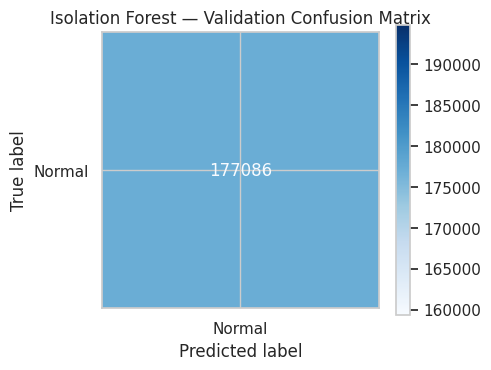

Isolation Forest — Test
              precision    recall  f1-score   support

  Normal (0)     0.7098    0.8512    0.7741     30535
 Anomaly (1)     0.9702    0.9329    0.9512    158432

    accuracy                         0.9197    188967
   macro avg     0.8400    0.8921    0.8626    188967
weighted avg     0.9281    0.9197    0.9226    188967

Accuracy : 0.9197
Precision: 0.9702
Recall   : 0.9329
F1-score : 0.9512
AUROC    : 0.9101


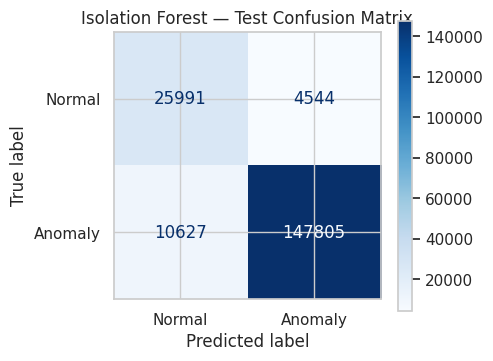

In [39]:
# under 12seconds
isolation_forest = IsolationForest(
    n_estimators=200,
    contamination=0.05,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

isolation_forest.fit(X_if)

# sklearn: predict() -> 1 normal, -1 anomaly
def iforest_predict(model, X):
    raw = model.predict(X)
    return np.where(raw == -1, 1, 0)

def iforest_score(model, X):
    # sklearn decision_function: larger = more normal
    # Convert to larger = more anomalous
    return -model.decision_function(X)

if_val_pred = iforest_predict(isolation_forest, X_val)
if_val_score = iforest_score(isolation_forest, X_val)

if_test_pred = iforest_predict(isolation_forest, X_test)
if_test_score = iforest_score(isolation_forest, X_test)

if_val_result = evaluate_model(
    "Isolation Forest — Validation",
    y_val,
    if_val_pred,
    if_val_score
)

show_confusion_matrix(
    y_val,
    if_val_pred,
    "Isolation Forest — Validation Confusion Matrix"
)

if_test_result = evaluate_model(
    "Isolation Forest — Test",
    y_test,
    if_test_pred,
    if_test_score
)

show_confusion_matrix(
    y_test,
    if_test_pred,
    "Isolation Forest — Test Confusion Matrix"
)


# 9. Random Forest

Random Forest is a supervised classifier. Unlike Isolation Forest and LOF, it directly learns from the `evil` labels.

it took 42secs to run the below cell

In [40]:
print("Random Forest training labels:")
print(y_rf.value_counts())

print("\nFull training labels:")
print(y_train.value_counts())

Random Forest training labels:
evil
0    763144
Name: count, dtype: int64

Full training labels:
evil
0    763144
Name: count, dtype: int64


In [41]:
print("TRAIN:")
print(train_p["evil"].value_counts())

print("\nVALIDATION:")
print(val_p["evil"].value_counts())

print("\nTEST:")
print(test_p["evil"].value_counts())

TRAIN:
evil
0    763144
Name: count, dtype: int64

VALIDATION:
evil
0    188967
Name: count, dtype: int64

TEST:
evil
1    158432
0     30535
Name: count, dtype: int64


Random Forest — Validation
              precision    recall  f1-score   support

  Normal (0)     1.0000    1.0000    1.0000    188967

    accuracy                         1.0000    188967
   macro avg     1.0000    1.0000    1.0000    188967
weighted avg     1.0000    1.0000    1.0000    188967

Accuracy : 1.0000
Precision: 0.0000
Recall   : 0.0000
F1-score : 0.0000


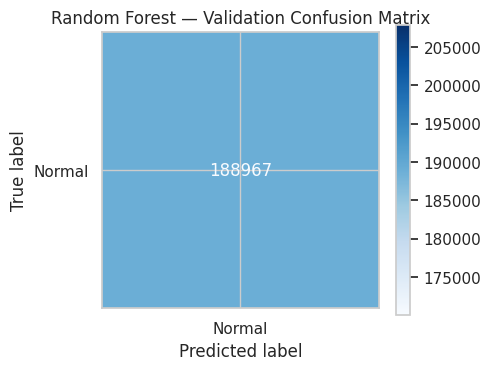

Random Forest — Test
              precision    recall  f1-score   support

  Normal (0)     0.1616    1.0000    0.2782     30535
 Anomaly (1)     0.0000    0.0000    0.0000    158432

    accuracy                         0.1616    188967
   macro avg     0.0808    0.5000    0.1391    188967
weighted avg     0.0261    0.1616    0.0450    188967

Accuracy : 0.1616
Precision: 0.0000
Recall   : 0.0000
F1-score : 0.0000
AUROC    : 0.5000


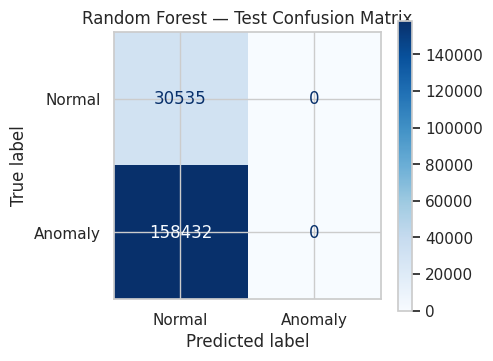

In [42]:
random_forest = RandomForestClassifier(
    n_estimators=200,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    class_weight="balanced_subsample"
)

random_forest.fit(X_rf, y_rf)

# Check if the model was trained on a single class
if random_forest.n_classes_ == 1:
    # If only one class (0) was seen during training,
    # the model can only predict class 0.
    # Therefore, the probability of class 1 (anomaly) is 0.
    rf_val_pred = np.zeros(len(X_val), dtype=int)
    rf_val_prob = np.zeros(len(X_val))

    rf_test_pred = np.zeros(len(X_test), dtype=int)
    rf_test_prob = np.zeros(len(X_test))
else:
    rf_val_pred = random_forest.predict(X_val)
    rf_val_prob = random_forest.predict_proba(X_val)[:, 1]

    rf_test_pred = random_forest.predict(X_test)
    rf_test_prob = random_forest.predict_proba(X_test)[:, 1]

rf_val_result = evaluate_model(
    "Random Forest — Validation",
    y_val,
    rf_val_pred,
    rf_val_prob
)

show_confusion_matrix(
    y_val,
    rf_val_pred,
    "Random Forest — Validation Confusion Matrix"
)

rf_test_result = evaluate_model(
    "Random Forest — Test",
    y_test,
    rf_test_pred,
    rf_test_prob
)

show_confusion_matrix(
    y_test,
    rf_test_pred,
    "Random Forest — Test Confusion Matrix"
)

# 10. Local Outlier Factor (LOF)

LOF identifies observations whose local density is substantially different from the density around their neighbours.

The supplied project presentation specifically discusses choosing `k` carefully and shows `n_neighbors = 4`. We therefore use `n_neighbors=4` here.

`novelty=True` is important because it allows the fitted LOF model to score new validation and test observations.
- it took 51 min

Local Outlier Factor — Validation
              precision    recall  f1-score   support

  Normal (0)     1.0000    0.9981    0.9991    188967

   micro avg     1.0000    0.9981    0.9991    188967
   macro avg     1.0000    0.9981    0.9991    188967
weighted avg     1.0000    0.9981    0.9991    188967

Accuracy : 0.9981
Precision: 0.0000
Recall   : 0.0000
F1-score : 0.0000


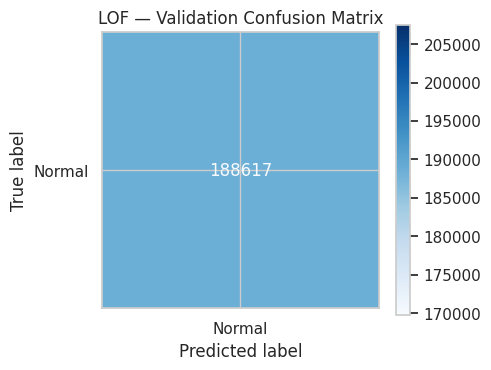

Local Outlier Factor — Test
              precision    recall  f1-score   support

  Normal (0)     0.9997    0.6060    0.7546     30535
 Anomaly (1)     0.9294    1.0000    0.9634    158432

    accuracy                         0.9363    188967
   macro avg     0.9646    0.8030    0.8590    188967
weighted avg     0.9408    0.9363    0.9297    188967

Accuracy : 0.9363
Precision: 0.9294
Recall   : 1.0000
F1-score : 0.9634
AUROC    : 0.9786


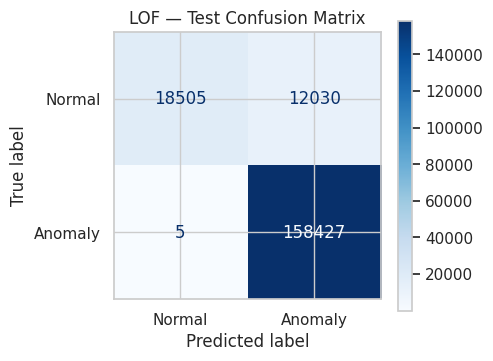

In [43]:
lof = LocalOutlierFactor(
    n_neighbors=4,
    contamination=0.05,
    novelty=True,
    n_jobs=-1
)

lof.fit(X_lof)

# sklearn: predict() -> 1 inlier, -1 outlier
def lof_predict(model, X):
    raw = model.predict(X)
    return np.where(raw == -1, 1, 0)

def lof_score(model, X):
    # decision_function: larger = more normal
    return -model.decision_function(X)

lof_val_pred = lof_predict(lof, X_val)
lof_val_score = lof_score(lof, X_val)

lof_test_pred = lof_predict(lof, X_test)
lof_test_score = lof_score(lof, X_test)

lof_val_result = evaluate_model(
    "Local Outlier Factor — Validation",
    y_val,
    lof_val_pred,
    lof_val_score
)

show_confusion_matrix(
    y_val,
    lof_val_pred,
    "LOF — Validation Confusion Matrix"
)

lof_test_result = evaluate_model(
    "Local Outlier Factor — Test",
    y_test,
    lof_test_pred,
    lof_test_score
)

show_confusion_matrix(
    y_test,
    lof_test_pred,
    "LOF — Test Confusion Matrix"
)


# 11. ROC curves

ROC curves show the trade-off between true-positive rate and false-positive rate over different score thresholds. AUROC provides a threshold-independent summary of ranking performance.


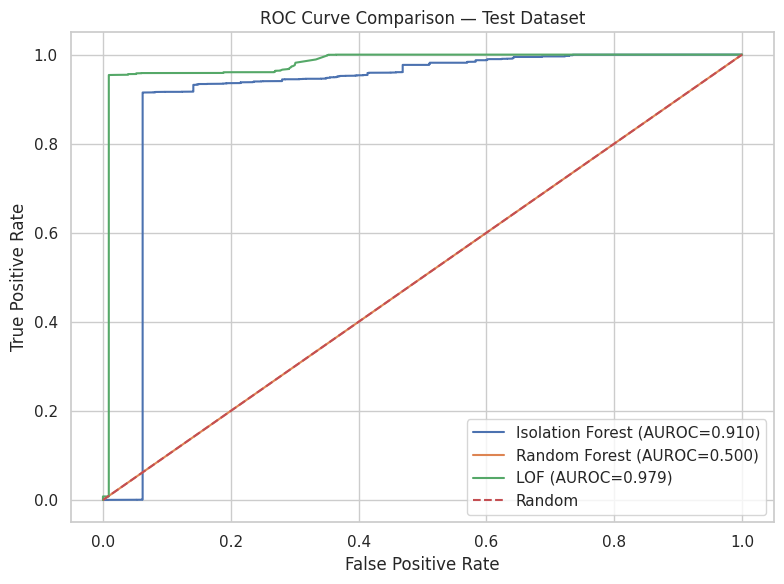

In [44]:
def plot_roc_curves(results, title):
    plt.figure(figsize=(8, 6))

    for name, y_true, score in results:
        fpr, tpr, _ = roc_curve(y_true, score)
        auc = roc_auc_score(y_true, score)
        plt.plot(fpr, tpr, label=f"{name} (AUROC={auc:.3f})")

    plt.plot([0, 1], [0, 1], linestyle="--", label="Random")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()


plot_roc_curves(
    [
        ("Isolation Forest", y_test, if_test_score),
        ("Random Forest", y_test, rf_test_prob),
        ("LOF", y_test, lof_test_score),
    ],
    "ROC Curve Comparison — Test Dataset"
)


# 12. Model comparison

This table collects the main test-set metrics in one place.


In [45]:
comparison = pd.DataFrame([
    {
        "Model": "Isolation Forest",
        "Accuracy": accuracy_score(y_test, if_test_pred),
        "Precision": precision_score(y_test, if_test_pred, zero_division=0),
        "Recall": recall_score(y_test, if_test_pred, zero_division=0),
        "F1": f1_score(y_test, if_test_pred, zero_division=0),
        "AUROC": roc_auc_score(y_test, if_test_score),
    },
    {
        "Model": "Random Forest",
        "Accuracy": accuracy_score(y_test, rf_test_pred),
        "Precision": precision_score(y_test, rf_test_pred, zero_division=0),
        "Recall": recall_score(y_test, rf_test_pred, zero_division=0),
        "F1": f1_score(y_test, rf_test_pred, zero_division=0),
        "AUROC": roc_auc_score(y_test, rf_test_prob),
    },
    {
        "Model": "Local Outlier Factor",
        "Accuracy": accuracy_score(y_test, lof_test_pred),
        "Precision": precision_score(y_test, lof_test_pred, zero_division=0),
        "Recall": recall_score(y_test, lof_test_pred, zero_division=0),
        "F1": f1_score(y_test, lof_test_pred, zero_division=0),
        "AUROC": roc_auc_score(y_test, lof_test_score),
    },
])

display(comparison.round(4))


,Model,Accuracy,Precision,Recall,F1,AUROC
0,Isolation Forest,0.9197,0.9702,0.9329,0.9512,0.9101
1,Random Forest,0.1616,0.0000,0.0000,0.0000,0.5000
2,Local Outlier Factor,0.9363,0.9294,1.0000,0.9634,0.9786


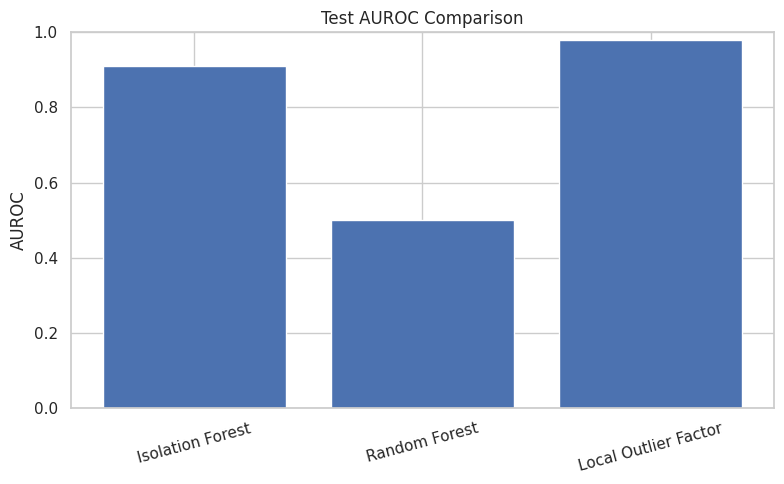

In [46]:
# Plot AUROC comparison
plt.figure(figsize=(8, 5))
plt.bar(comparison["Model"], comparison["AUROC"])
plt.ylim(0, 1)
plt.ylabel("AUROC")
plt.title("Test AUROC Comparison")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


In [47]:
# Start from an actual test observation so the categorical values are valid.
synthetic_normal = X_test.iloc[[0]].copy()

# Create a deliberately altered observation.
synthetic_anomaly = synthetic_normal.copy()

# Make several fields unusual within the preprocessed feature space.
synthetic_anomaly.iloc[0, synthetic_anomaly.columns.get_loc("processId")] = 1
synthetic_anomaly.iloc[0, synthetic_anomaly.columns.get_loc("parentProcessId")] = 1
synthetic_anomaly.iloc[0, synthetic_anomaly.columns.get_loc("userId")] = 1
synthetic_anomaly.iloc[0, synthetic_anomaly.columns.get_loc("mountNamespace")] = 1
synthetic_anomaly.iloc[0, synthetic_anomaly.columns.get_loc("argsNum")] = 50
synthetic_anomaly.iloc[0, synthetic_anomaly.columns.get_loc("returnValue")] = 2

synthetic = pd.concat(
    [synthetic_normal, synthetic_anomaly],
    ignore_index=True
)

print("Synthetic samples:")
display(synthetic)

# Predictions
synthetic_if = iforest_predict(isolation_forest, synthetic)
synthetic_rf = random_forest.predict(synthetic)
synthetic_lof = lof_predict(lof, synthetic)

synthetic_results = pd.DataFrame({
    "Sample": ["Normal-like", "Altered anomaly-like"],
    "Isolation Forest": synthetic_if,
    "Random Forest": synthetic_rf,
    "LOF": synthetic_lof,
})

display(synthetic_results)


Synthetic samples:


,processId,parentProcessId,userId,mountNamespace,processName,eventId,eventName,argsNum,returnValue
0,1.0,0.0,0.0,1.0,91.0,41.0,40.0,3.0,1.0
1,1.0,1.0,1.0,1.0,91.0,41.0,40.0,50.0,2.0


,Sample,Isolation Forest,Random Forest,LOF
0,Normal-like,1,0,0
1,Altered anomaly-like,1,0,1


# 14. Save predictions

This cell creates a compact test-set prediction file containing the true label and predictions/scores from all three models.


In [51]:
from pathlib import Path
predictions = pd.DataFrame({
    "evil_true": y_test.to_numpy(),
    "isolation_forest_pred": if_test_pred,
    "isolation_forest_score": if_test_score,
    "random_forest_pred": rf_test_pred,
    "random_forest_probability": rf_test_prob,
    "lof_pred": lof_test_pred,
    "lof_score": lof_test_score,
})


OUTPUT_DIR = Path("/content/drive/MyDrive/saved/results")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

prediction_file = OUTPUT_DIR / "beth_model_predictions.csv"
predictions.to_csv(prediction_file, index=False)

comparison_file = OUTPUT_DIR / "model_comparison.csv"
comparison.to_csv(comparison_file, index=False)

print("Saved:", prediction_file)
print("Saved:", comparison_file)


Saved: /content/drive/MyDrive/saved/results/beth_model_predictions.csv
Saved: /content/drive/MyDrive/saved/results/model_comparison.csv
